In [32]:
import pandas as pd

In [33]:
low_mass_satellite_df = pd.read_parquet ('../../data/low_mass_satellite_df_annuli_revised.parquet')

In [34]:
low_mass_satellite_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
439,37.0,0.174505,8.905776,-0.052619,8.682093,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
440,37.0,0.523516,8.636583,-0.643683,8.302815,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
441,37.0,0.872526,8.421218,-1.414926,7.867777,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
442,37.0,1.221537,8.243556,-1.699316,7.714798,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
443,37.0,1.570547,8.094305,-1.657207,7.711024,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54860,593573.0,0.461125,7.915781,-3.874264,7.566107,1,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321
54861,593573.0,0.768541,7.496673,-2.880743,7.366165,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321
54862,593573.0,1.075957,7.168706,-3.435107,7.380437,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321
54863,593573.0,1.383374,6.925375,-3.566125,7.352052,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321


<Axes: >

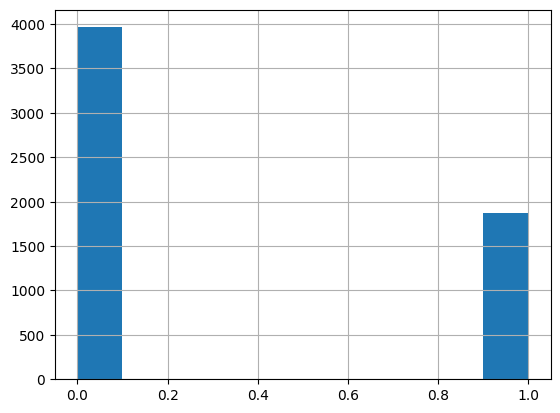

In [35]:
low_mass_satellite_df['quenching_vector'].hist()

In [36]:
galaxy_class_counts = low_mass_satellite_df.groupby("subID")["quenching_vector"].nunique()

# count galaxies with only one class vs. two classes
num_single_class_galaxies = (galaxy_class_counts == 1).sum()
num_two_class_galaxies = (galaxy_class_counts > 1).sum()

print(f"Number of galaxies with only one class: {num_single_class_galaxies}")
print(f"Number of galaxies with two classes: {num_two_class_galaxies}")

Number of galaxies with only one class: 555
Number of galaxies with two classes: 270


In [37]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import RobustScaler

# 'BHMass', 'BHCum_QM', 'Mhalo', 'overdens', and 'bulge' are the features wer are testing
low_mass_satellite_df = low_mass_satellite_df.drop(columns=["class", "BH_cumQM", "BH_cumRM", "global_SFRs", "avg_SFR","avg_gas_mass", "gas_mass", "Bfld", "veldisp", "BH_AGN", "bulge"])
low_mass_satellite_df.duplicated()

# X = low_mass_satellite_df.drop(['quenching_vector'], axis=1)
# y = low_mass_satellite_df['quenching_vector']

439      False
440      False
441      False
442      False
443      False
         ...  
54860    False
54861    False
54862    False
54863    False
54864    False
Length: 5831, dtype: bool

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.8, 'scale_pos_weight': 1.0, 'n_estimators': 100, 'min_child_weight': 25, 'max_depth': 1, 'learning_rate': 0.01, 'lambda': 4.0, 'gamma': 0.4, 'colsample_bytree': 1.0, 'alpha': 5.0}


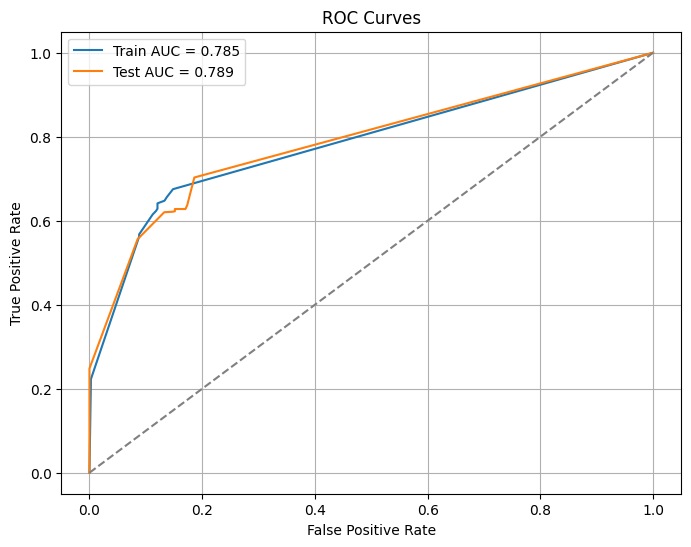

Gap (Train - Test AUC): -0.0043
Overfitting ratio (Train/Test AUC): 0.9945
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.8, 'scale_pos_weight': 1.0, 'n_estimators': 100, 'min_child_weight': 30, 'max_depth': 1, 'learning_rate': 0.01, 'lambda': 5.0, 'gamma': 0.4, 'colsample_bytree': 1.0, 'alpha': 4.0}


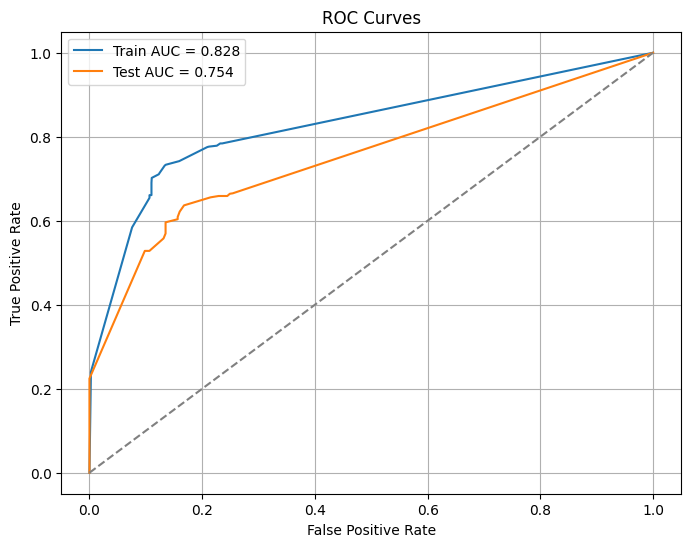

Gap (Train - Test AUC): 0.0738
Overfitting ratio (Train/Test AUC): 1.0978
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.8, 'scale_pos_weight': 1.0, 'n_estimators': 100, 'min_child_weight': 25, 'max_depth': 1, 'learning_rate': 0.01, 'lambda': 6.0, 'gamma': 0.6, 'colsample_bytree': 1.0, 'alpha': 4.0}


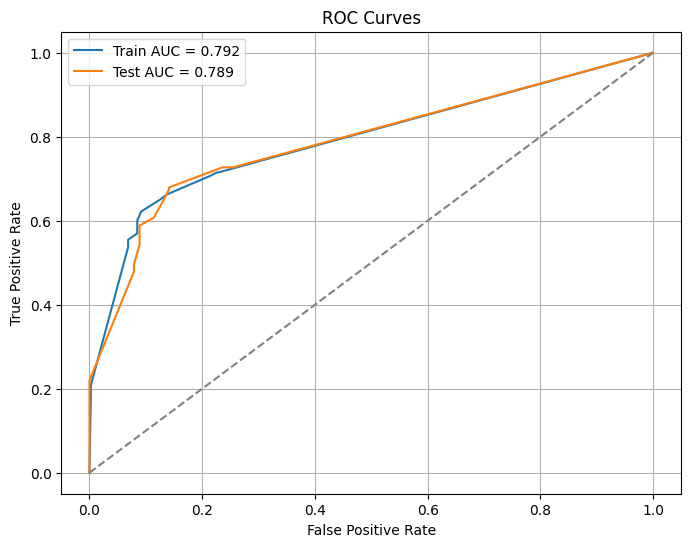

Gap (Train - Test AUC): 0.0028
Overfitting ratio (Train/Test AUC): 1.0036
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.8, 'scale_pos_weight': 1.0, 'n_estimators': 100, 'min_child_weight': 30, 'max_depth': 1, 'learning_rate': 0.01, 'lambda': 5.0, 'gamma': 0.6, 'colsample_bytree': 1.0, 'alpha': 5.0}


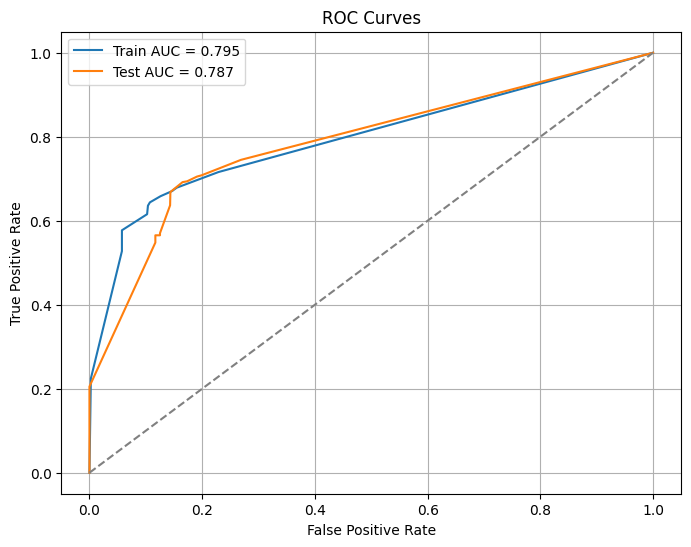

Gap (Train - Test AUC): 0.0086
Overfitting ratio (Train/Test AUC): 1.0110
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.8, 'scale_pos_weight': 1.0, 'n_estimators': 100, 'min_child_weight': 25, 'max_depth': 1, 'learning_rate': 0.05, 'lambda': 6.0, 'gamma': 0.2, 'colsample_bytree': 1.0, 'alpha': 5.0}


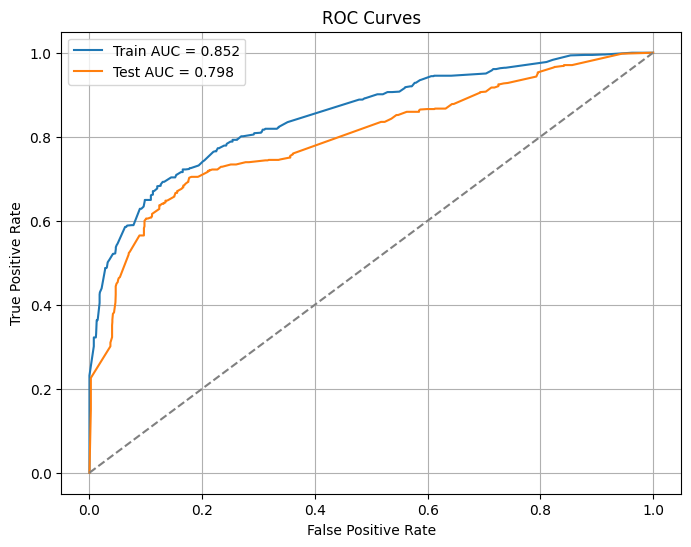

Gap (Train - Test AUC): 0.0538
Overfitting ratio (Train/Test AUC): 1.0673
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.8, 'scale_pos_weight': 1.0, 'n_estimators': 100, 'min_child_weight': 30, 'max_depth': 1, 'learning_rate': 0.01, 'lambda': 6.0, 'gamma': 0.6, 'colsample_bytree': 1.0, 'alpha': 6.0}


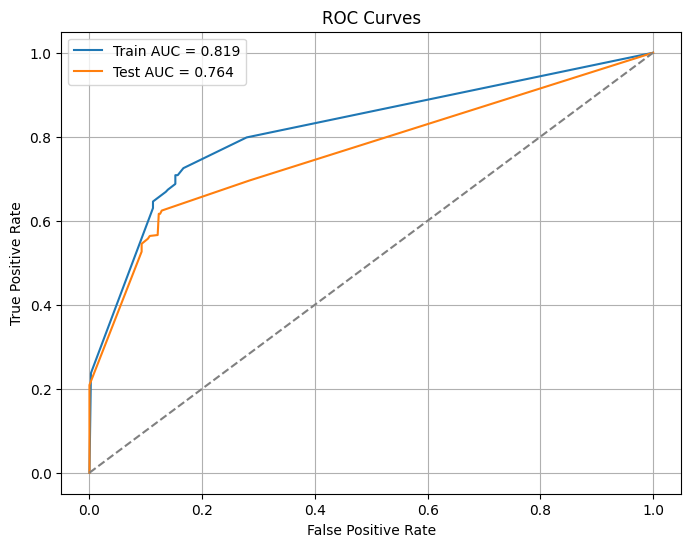

Gap (Train - Test AUC): 0.0543
Overfitting ratio (Train/Test AUC): 1.0711
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.8, 'scale_pos_weight': 1.0, 'n_estimators': 150, 'min_child_weight': 30, 'max_depth': 1, 'learning_rate': 0.01, 'lambda': 6.0, 'gamma': 0.2, 'colsample_bytree': 1.0, 'alpha': 4.0}


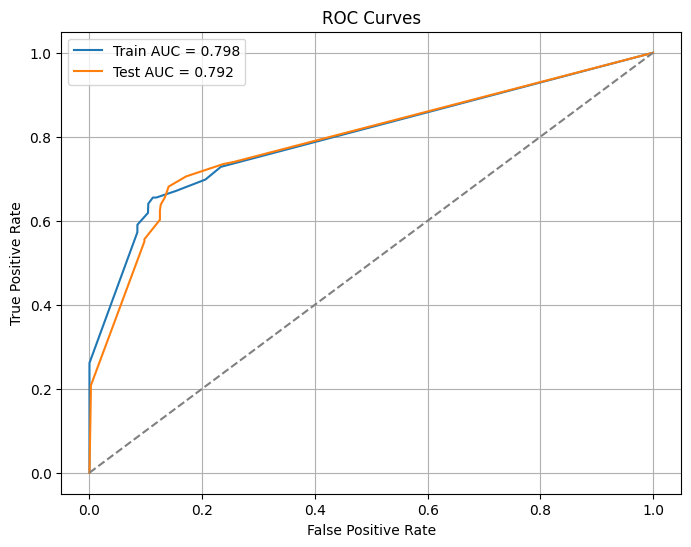

Gap (Train - Test AUC): 0.0053
Overfitting ratio (Train/Test AUC): 1.0067
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.8, 'scale_pos_weight': 1.0, 'n_estimators': 100, 'min_child_weight': 30, 'max_depth': 1, 'learning_rate': 0.05, 'lambda': 6.0, 'gamma': 0.2, 'colsample_bytree': 1.0, 'alpha': 4.0}


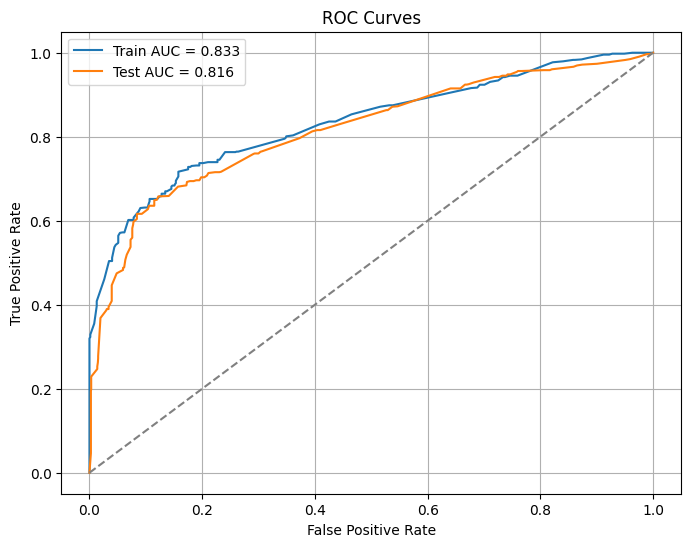

Gap (Train - Test AUC): 0.0169
Overfitting ratio (Train/Test AUC): 1.0207
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.8, 'scale_pos_weight': 1.0, 'n_estimators': 100, 'min_child_weight': 25, 'max_depth': 1, 'learning_rate': 0.01, 'lambda': 5.0, 'gamma': 0.6, 'colsample_bytree': 1.0, 'alpha': 5.0}


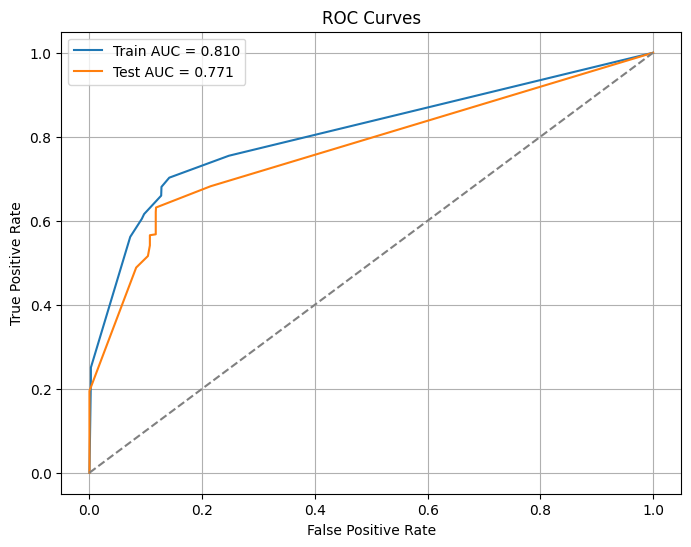

Gap (Train - Test AUC): 0.0390
Overfitting ratio (Train/Test AUC): 1.0506
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.8, 'scale_pos_weight': 1.0, 'n_estimators': 150, 'min_child_weight': 25, 'max_depth': 1, 'learning_rate': 0.01, 'lambda': 6.0, 'gamma': 0.4, 'colsample_bytree': 1.0, 'alpha': 5.0}


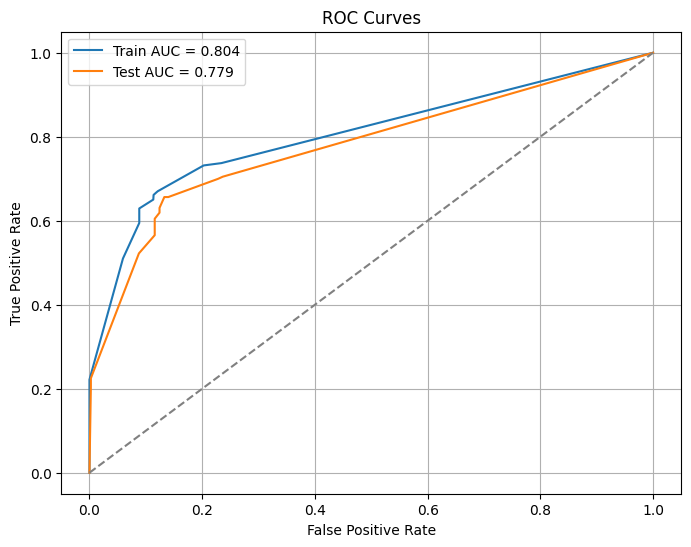

Gap (Train - Test AUC): 0.0252
Overfitting ratio (Train/Test AUC): 1.0323

Average AUC over 10 runs:
Train AUC: Mean = 0.8115, Std = 0.0201
Test AUC:  Mean = 0.7840, Std = 0.0168
Train F1: Mean = 0.6661, Std = 0.0202
Test F1:  Mean = 0.6187, Std = 0.0179

Gap stats: Mean = 0.0275, Std = 0.0250, Min = -0.0043, Max = 0.0738
Overfitting ratio stats: Mean = 1.0356, Std = 0.0328


In [38]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score

# splitting galaxies into test/train based on subID
unique_galaxies = np.unique(low_mass_satellite_df['subID'])

train_aucs = []
test_aucs = []
feature_importances_list = []
feature_names = None
train_f1s = []
test_f1s = []


for seed in range(10):
    train_galaxies, test_galaxies = train_test_split(unique_galaxies, test_size=0.5, random_state=seed)

    train_data = low_mass_satellite_df[low_mass_satellite_df['subID'].isin(train_galaxies)]
    test_data = low_mass_satellite_df[low_mass_satellite_df['subID'].isin(test_galaxies)]

    X_train, y_train = train_data.drop(columns=['quenching_vector', 'subID']), train_data['quenching_vector']
    X_test, y_test = test_data.drop(columns=['quenching_vector', 'subID']), test_data['quenching_vector']

    if feature_names is None:
        feature_names = X_train.columns.tolist()
    # scaling
    scaler = RobustScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    xgb_clf = xgb.XGBClassifier(random_state=seed, objective='binary:logistic')

    param_grid_xgb = {
    'n_estimators': [100, 150],
    'max_depth': [1],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [1.0],
    'min_child_weight': [25, 30],
    'gamma': [0.2, 0.4, 0.6],
    'lambda': [4.0, 5.0, 6.0],
    'alpha': [4.0, 5.0, 6.0],
    'scale_pos_weight': [1.0]
    }

    random_search_xgb = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_grid_xgb,
    n_iter=10,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1, 
    random_state=seed,
    verbose=2,
    )

    random_search_xgb.fit(X_train_scaled, y_train)

    best_xgb = random_search_xgb.best_estimator_
    print(random_search_xgb.best_params_)

    y_train_prob = best_xgb.predict_proba(X_train_scaled)[:, 1]
    y_test_prob = best_xgb.predict_proba(X_test_scaled)[:, 1]

    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)



    # ROC curves
    plt.figure(figsize=(8,6))
    plt.plot(fpr_train, tpr_train, label=f'Train AUC = {roc_auc_score(y_train, y_train_prob):.3f}')
    plt.plot(fpr_test, tpr_test, label=f'Test AUC = {roc_auc_score(y_test, y_test_prob):.3f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # aucs and feature importance
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    feature_importances_list.append(best_xgb.feature_importances_)
    
    train_aucs.append(train_auc)
    test_aucs.append(test_auc)
    gap = train_auc - test_auc
    print(f"Gap (Train - Test AUC): {gap:.4f}")
    print(f"Overfitting ratio (Train/Test AUC): {train_auc / test_auc:.4f}")

    y_train_pred = best_xgb.predict(X_train_scaled)
    y_test_pred = best_xgb.predict(X_test_scaled)

    # f1 scores
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    train_f1s.append(train_f1)
    test_f1s.append(test_f1)
    

print("\nAverage AUC over 10 runs:")
print(f"Train AUC: Mean = {np.mean(train_aucs):.4f}, Std = {np.std(train_aucs):.4f}")
print(f"Test AUC:  Mean = {np.mean(test_aucs):.4f}, Std = {np.std(test_aucs):.4f}")
print(f"Train F1: Mean = {np.mean(train_f1s):.4f}, Std = {np.std(train_f1s):.4f}")
print(f"Test F1:  Mean = {np.mean(test_f1s):.4f}, Std = {np.std(test_f1s):.4f}")
gaps = [train - test for train, test in zip(train_aucs, test_aucs)]
overfit_ratios = [train / test for train, test in zip(train_aucs, test_aucs)]
print(f"\nGap stats: Mean = {np.mean(gaps):.4f}, Std = {np.std(gaps):.4f}, Min = {np.min(gaps):.4f}, Max = {np.max(gaps):.4f}")
print(f"Overfitting ratio stats: Mean = {np.mean(overfit_ratios):.4f}, Std = {np.std(overfit_ratios):.4f}")


=== Average Feature Importances ===
      Feature  Mean Importance   Std Dev
4       Mhalo         0.626122  0.055112
3      BHMass         0.335167  0.037444
5    overdens         0.018686  0.039919
2      s_mass         0.013600  0.027497
1  avg_s_mass         0.006424  0.019273
0   bin_radii         0.000000  0.000000


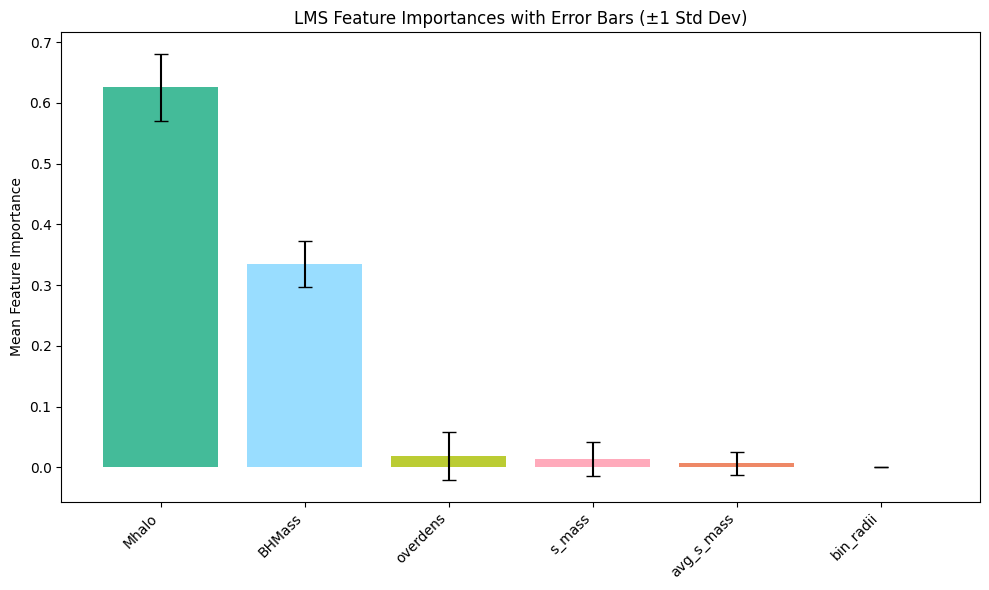

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
feature_colors = {
    'bin_radii': '#77AADD',
    'avg_s_mass': '#EE8866',
    's_mass': '#FFAABB',
    'BHMass': '#99DDFF',
    'Mhalo': '#44BB99',
    'overdens': '#BBCC33',
    'bulge': '#AAAA00',
    'BH_AGN': '#DDDDDD',
}

# importances + stds across 10 runs
importances_array = np.array(feature_importances_list)
importance_means = np.mean(importances_array, axis=0)
importance_stds = np.std(importances_array, axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean Importance': importance_means,
    'Std Dev': importance_stds
}).sort_values(by='Mean Importance', ascending=False)

print("\n=== Average Feature Importances ===")
print(importance_df)

colors = [feature_colors[feat] for feat in importance_df['Feature']]
# Plot
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Mean Importance'], yerr=importance_df['Std Dev'], capsize=5, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean Feature Importance")
plt.title("LMS Feature Importances with Error Bars (±1 Std Dev)")
plt.tight_layout()
plt.show()

In [40]:
# from sklearn.metrics import f1_score
# y_train_pred = best_rf.predict(X_train_scaled)
# y_test_pred = best_rf.predict(X_test_scaled)

# # f1 scores
# train_f1 = f1_score(y_train, y_train_pred)
# test_f1 = f1_score(y_test, y_test_pred)

# print(f"Train F1 Score: {train_f1:.3f}")
# print(f"Test F1 Score: {test_f1:.3f}")

In [41]:
low_mass_satellite_df.corr()

,subID,bin_radii,avg_s_mass,quenching_vector,s_mass,BHMass,Mhalo,overdens
subID,1.000000,0.012483,-0.147451,-0.461102,-0.119578,-0.018875,-0.806539,-0.187313
bin_radii,0.012483,1.000000,-0.763786,-0.014416,0.008626,0.006630,-0.009713,-0.002019
avg_s_mass,-0.147451,-0.763786,1.000000,-0.006994,0.400759,0.370520,0.095505,0.053804
quenching_vector,-0.461102,-0.014416,-0.006994,1.000000,-0.141393,-0.204118,0.447145,0.085638
s_mass,-0.119578,0.008626,0.400759,-0.141393,1.000000,0.872315,0.042330,0.074692
BHMass,-0.018875,0.006630,0.370520,-0.204118,0.872315,1.000000,-0.039114,0.019820
Mhalo,-0.806539,-0.009713,0.095505,0.447145,0.042330,-0.039114,1.000000,0.111680
overdens,-0.187313,-0.002019,0.053804,0.085638,0.074692,0.019820,0.111680,1.000000


In [42]:
low_mass_satellite_df.corr()

,subID,bin_radii,avg_s_mass,quenching_vector,s_mass,BHMass,Mhalo,overdens
subID,1.000000,0.012483,-0.147451,-0.461102,-0.119578,-0.018875,-0.806539,-0.187313
bin_radii,0.012483,1.000000,-0.763786,-0.014416,0.008626,0.006630,-0.009713,-0.002019
avg_s_mass,-0.147451,-0.763786,1.000000,-0.006994,0.400759,0.370520,0.095505,0.053804
quenching_vector,-0.461102,-0.014416,-0.006994,1.000000,-0.141393,-0.204118,0.447145,0.085638
s_mass,-0.119578,0.008626,0.400759,-0.141393,1.000000,0.872315,0.042330,0.074692
BHMass,-0.018875,0.006630,0.370520,-0.204118,0.872315,1.000000,-0.039114,0.019820
Mhalo,-0.806539,-0.009713,0.095505,0.447145,0.042330,-0.039114,1.000000,0.111680
overdens,-0.187313,-0.002019,0.053804,0.085638,0.074692,0.019820,0.111680,1.000000


In [43]:
import os
# Define your directory and file name
directory = 'xg_classification_outputs'
filename = 'lms_xg_quenching.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
importance_df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

DataFrame saved to xg_classification_outputs\lms_xg_quenching.csv


In [44]:
train_mean = round(np.mean(train_aucs), 2)
test_mean = round(np.mean(test_aucs), 2)
print(train_mean)
df = pd.DataFrame({
    'Train AUC': [train_mean],
    'Test AUC': [test_mean]
})

print(df)
import os
# Define your directory and file name
directory = 'xg_classification_outputs'
filename = 'lms_xg_quenching_auc.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

0.81
   Train AUC  Test AUC
0       0.81      0.78
DataFrame saved to xg_classification_outputs\lms_xg_quenching_auc.csv
